
  Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       250
           1       0.79      0.81      0.80       244

    accuracy                           0.80       494
   macro avg       0.80      0.80      0.80       494
weighted avg       0.80      0.80      0.80       494

ROC-AUC: 0.8926

  Random Forest
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       250
           1       0.93      0.88      0.90       244

    accuracy                           0.91       494
   macro avg       0.91      0.91      0.91       494
weighted avg       0.91      0.91      0.91       494

ROC-AUC: 0.9680

  Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       250
           1       0.90      0.86      0.88       244

    accuracy                           0.88       494
   macro avg       0.88      0.88  

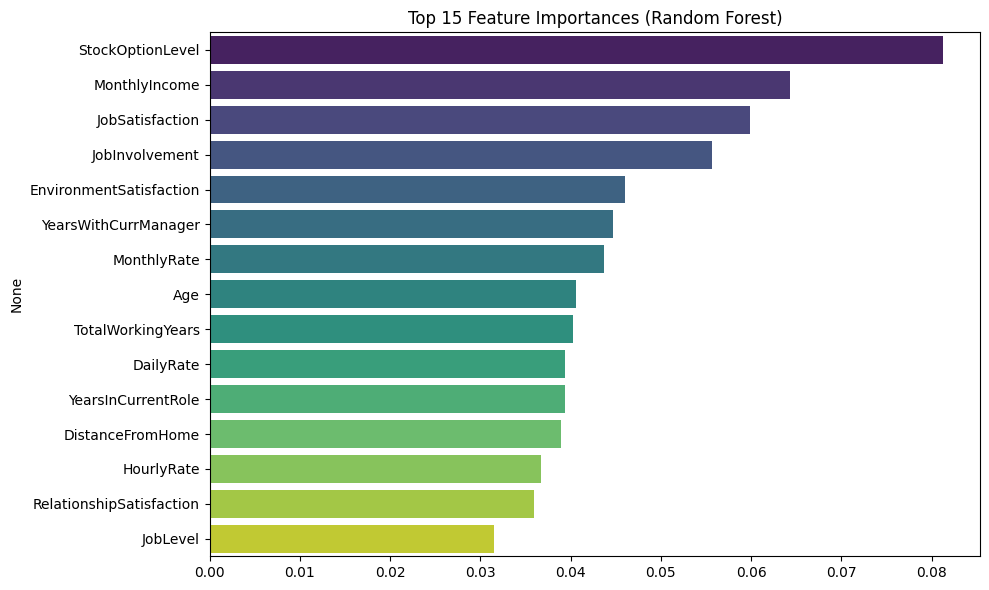

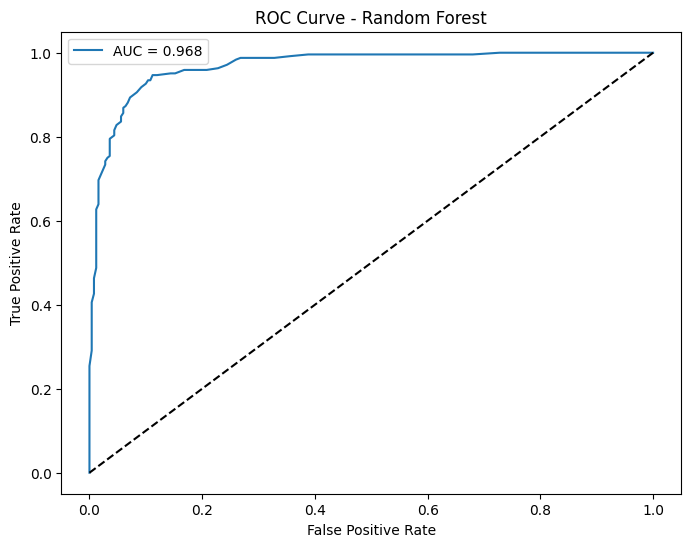

✅ hr_with_predictions.csv exported successfully!


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load & Clean ──
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop useless columns
df.drop(['EmployeeCount','EmployeeNumber','Over18','StandardHours'], 
        axis=1, inplace=True)

# ── Encode Categorical Columns ──
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# ── Features & Target ──
X = df.drop('Attrition', axis=1)
y = df['Attrition']   # 1 = Yes, 0 = No

# ── Handle Class Imbalance with SMOTE ──
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# ── Train/Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42)

# ── Scale Features ──
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── Train Models ──
models = {
    'Logistic Regression' : LogisticRegression(),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")

# ── Best Model: Random Forest - Feature Importance ──
rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, 
                     index=X.columns).sort_values(ascending=False)[:15]

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# ── ROC Curve ──
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# ── Export Predictions for Power BI ──
original_df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
original_df.drop(['EmployeeCount','Over18','StandardHours'], axis=1, inplace=True)

cat_cols = original_df.select_dtypes(include='object').columns
for col in cat_cols:
    original_df[col] = le.fit_transform(original_df[col])

X_all = original_df.drop('Attrition', axis=1).drop('EmployeeNumber', 
                          axis=1, errors='ignore')
X_all_scaled = scaler.transform(X_all) if X_all.shape[1] == X_train.shape[1] \
               else scaler.transform(
                   StandardScaler().fit_transform(X_all))

# Use original (non-SMOTE) for predictions
df_orig = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_orig.drop(['EmployeeCount','Over18','StandardHours'], axis=1, inplace=True)
cat_orig = df_orig.select_dtypes(include='object').columns
for col in cat_orig:
    df_orig[col] = LabelEncoder().fit_transform(df_orig[col])

X_orig = df_orig.drop('Attrition', axis=1)
X_orig_scaled = StandardScaler().fit_transform(X_orig)

rf_plain = RandomForestClassifier(n_estimators=100, random_state=42)
rf_plain.fit(X_orig_scaled, df_orig['Attrition'])
probs = rf_plain.predict_proba(X_orig_scaled)[:,1]

output = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
output['Attrition_Probability'] = (probs * 100).round(2)
output['Risk_Category'] = pd.cut(probs, 
                                  bins=[0, 0.3, 0.6, 1.0],
                                  labels=['Low Risk','Medium Risk','High Risk'])
output.to_csv('hr_with_predictions.csv', index=False)
print("✅ hr_with_predictions.csv exported successfully!")